**Prática de Segmentação de imagens**

In [1]:
# %pip install opencv-python matplotlib numpy
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1) Faça a plotagem do histograma da imagem, observando o histograma, escolha um valor para definir um threshold

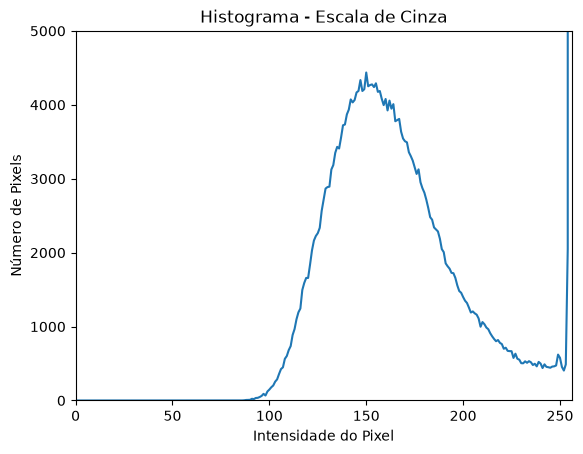

In [2]:
img1 = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

# plt.imshow(img1, cmap='gray', vmin=0, vmax=255)

histograma = cv2.calcHist([img1], [0], None, [256], [0, 256])

plt.figure()
plt.title("Histograma - Escala de Cinza")
plt.xlabel("Intensidade do Pixel")
plt.ylabel("Número de Pixels")
plt.plot(histograma)
plt.xlim([0, 256])
plt.ylim([0, 5000])
plt.show()

# Escolheria o limiar 250 para poder cortar a imagem em duas classes.

2)	Segmentação utilizando a técnica de Threshold Adaptativo (implementar o algortimo). Faça a aplicação do Threshold com e sem suavização prévia

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

def otsu(img):
    histograma = cv2.calcHist([img], [0], None, [256], [0, 256])
    total_pixel = img.shape[0] * img.shape[1]

    hist_norm = (histograma / total_pixel).ravel()

    niveis = np.arange(256)

    mg = np.sum(niveis * hist_norm)
    varG = np.sum(hist_norm * (niveis - mg) ** 2)

    k_maximizador = -1
    eta_g = -1

    variancias_entre_classes = np.zeros(256)

    for k in range(255):
        P1 = np.sum(hist_norm[:k+1])
        P2 = np.sum(hist_norm[k+1:])

        if P1 == 0 or P2 == 0:
            continue

        m1 = np.sum(niveis[:k+1] * hist_norm[:k+1]) / P1
        m2 = np.sum(niveis[k+1:] * hist_norm[k+1:]) / P2

        varB = P1 * (m1 - mg) ** 2 + P2 * (m2 - mg) ** 2

        variancias_entre_classes[k] = varB

        if varG == 0:
            eta = 0
        else:
            eta = varB / varG

        if eta_g < eta:
            eta_g = eta
            k_maximizador = k

    return k_maximizador, eta_g, hist_norm, variancias_entre_classes

k_maximizador, eta_g, hist_norm, var = otsu(img)

print("Limiar encontrado:", k_maximizador)
print("Separabilidade:", eta_g)

Limiar encontrado: 204
Separabilidade: 0.9152001652405201


3) Segmentação utilizando a técnica de Otsu (implementar) . Faça a aplicação do Threshold com e sem suavização prévia. Mostre um gráfico com o histograma juntamente com a variância entre classes (Exemplo: https://en.wikipedia.org/wiki/File:Otsu%27s_Method_Visualization.gif)

Limiar Otsu sem suavização: 204
Separabilidade sem suavização: 0.9152001652405201
Limiar Otsu com suavização: 206
Separabilidade com suavização: 0.9222218702254199


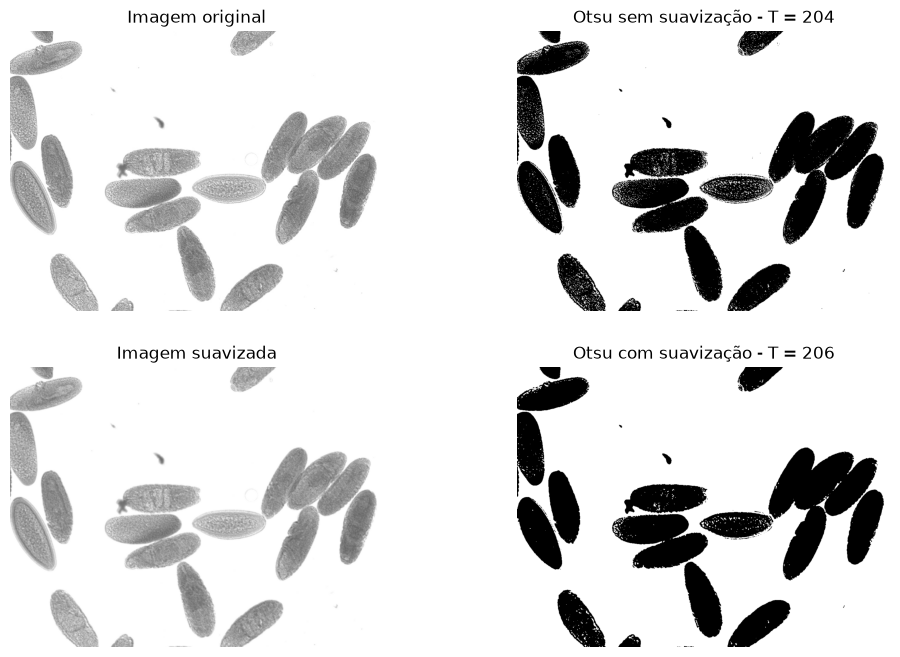

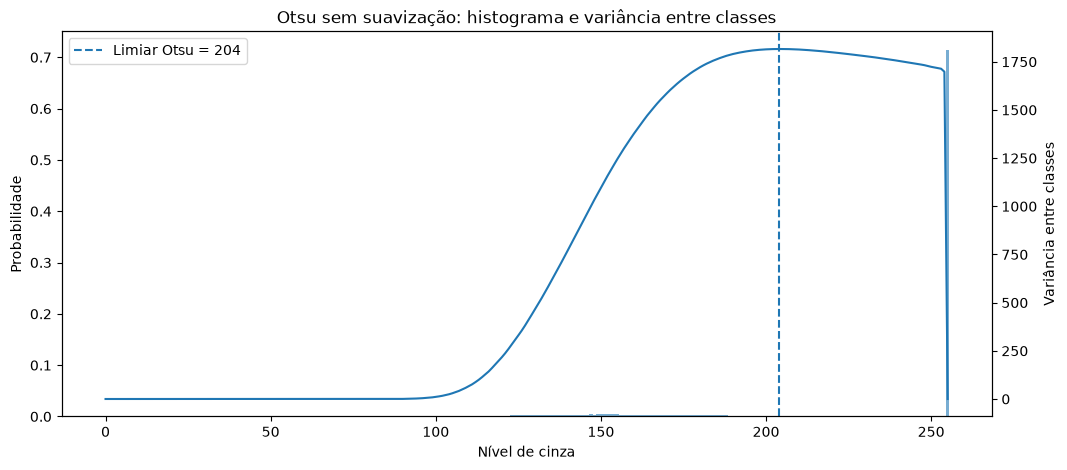

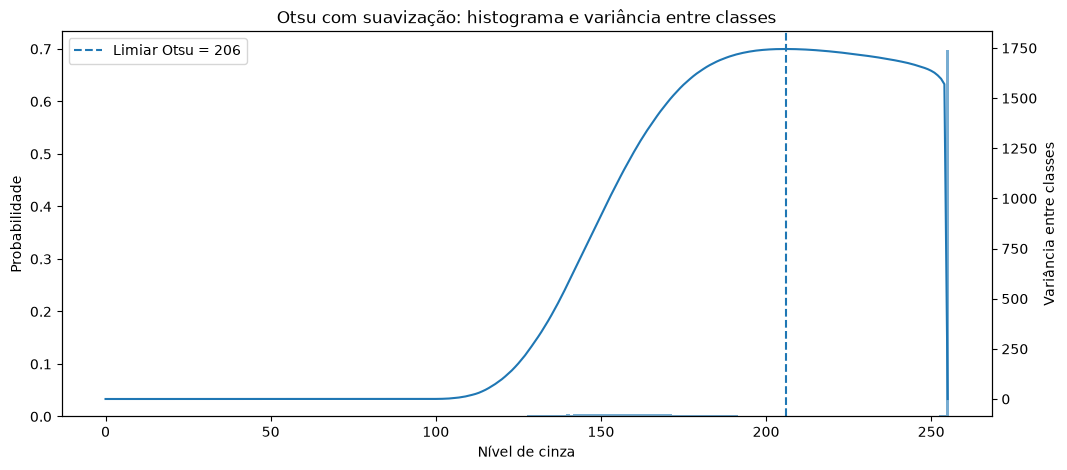

In [4]:
# Leitura da imagem
img = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

# Otsu sem suavização
limiar, eta, hist_sem, varB_sem = otsu(img)

img_segmentada_sem = np.zeros_like(img)
img_segmentada_sem[img > limiar] = 255

print("Limiar Otsu sem suavização:", limiar)
print("Separabilidade sem suavização:", eta)

# Otsu com suavização
img_suavizada = cv2.GaussianBlur(img, (5, 5), 0)

limiar_suav, eta_suav, hist_com, varB_com = otsu(img_suavizada)

img_segmentada_com = np.zeros_like(img_suavizada)
img_segmentada_com[img_suavizada > limiar_suav] = 255

print("Limiar Otsu com suavização:", limiar_suav)
print("Separabilidade com suavização:", eta_suav)


# Visualização dos resultados
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img_segmentada_sem, cmap="gray", vmin=0, vmax=255)
plt.title(f"Otsu sem suavização - T = {limiar}")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(img_suavizada, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem suavizada")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_segmentada_com, cmap="gray", vmin=0, vmax=255)
plt.title(f"Otsu com suavização - T = {limiar_suav}")
plt.axis("off")

plt.show()


# Histograma e variância entre classes — sem suavização
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(np.arange(256), hist_sem, width=1.0, alpha=0.6)
ax1.set_xlabel("Nível de cinza")
ax1.set_ylabel("Probabilidade")
ax1.set_title("Otsu sem suavização: histograma e variância entre classes")

ax1.axvline(limiar, linestyle="--", label=f"Limiar Otsu = {limiar}")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(np.arange(256), varB_sem)
ax2.set_ylabel("Variância entre classes")

plt.show()


# Histograma e variância entre classes — com suavização
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(np.arange(256), hist_com, width=1.0, alpha=0.6)
ax1.set_xlabel("Nível de cinza")
ax1.set_ylabel("Probabilidade")
ax1.set_title("Otsu com suavização: histograma e variância entre classes")

ax1.axvline(limiar_suav, linestyle="--", label=f"Limiar Otsu = {limiar_suav}")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(np.arange(256), varB_com)
ax2.set_ylabel("Variância entre classes")

plt.show()

In [ ]:
4)	Aplique o Otsu para a imagem HE.jpg, madrill.tiff e  Lenna.jpg (use antes a conversão da imagem para tons de cinza)

SyntaxError: unmatched ')' (615230310.py, line 1)

Limiar Otsu = 178
Separabilidade = 0.7167



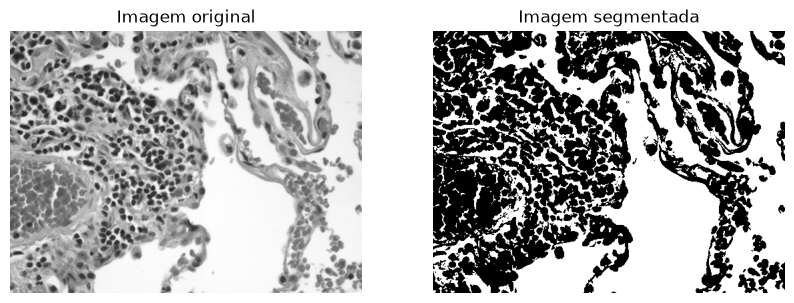

Limiar Otsu = 128
Separabilidade = 0.6817



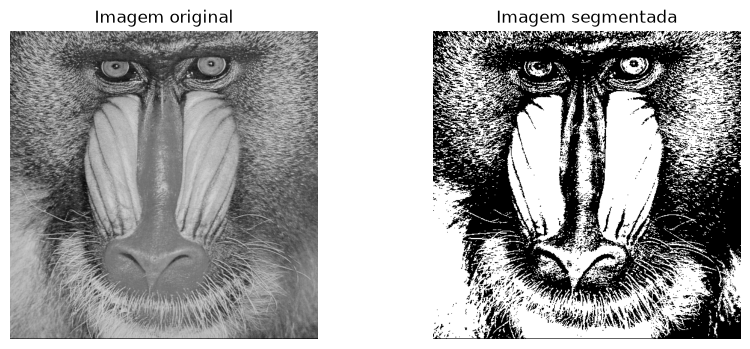

Limiar Otsu = 112
Separabilidade = 0.7020



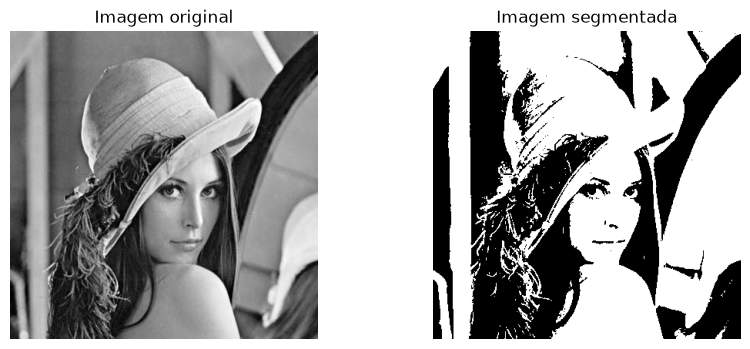

In [8]:
img1 = cv2.imread("HE.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("madrill.tiff", cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread("Lenna.jpg", cv2.IMREAD_GRAYSCALE)

for img in (img1, img2, img3):
    limiar, eta, hist_img, varB_img = otsu(img)
    img_segmentada = np.zeros_like(img)
    img_segmentada[img > limiar] = 255

    print(f"Limiar Otsu = {limiar}")
    print(f"Separabilidade = {eta:.4f}")
    print()

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Imagem original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_segmentada, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Imagem segmentada")
    plt.axis("off")

    plt.show()
